# Где дешевле жить? Предсказание цен в Airbnb - учимся генерировать признаки и интерпретировать результаты модели

✅ Все импорты готовы!
Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
Путь к файлам: /kaggle/input/new-york-city-airbnb-open-data
Размер датасета: (48895, 16)

Колонки: ['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5 

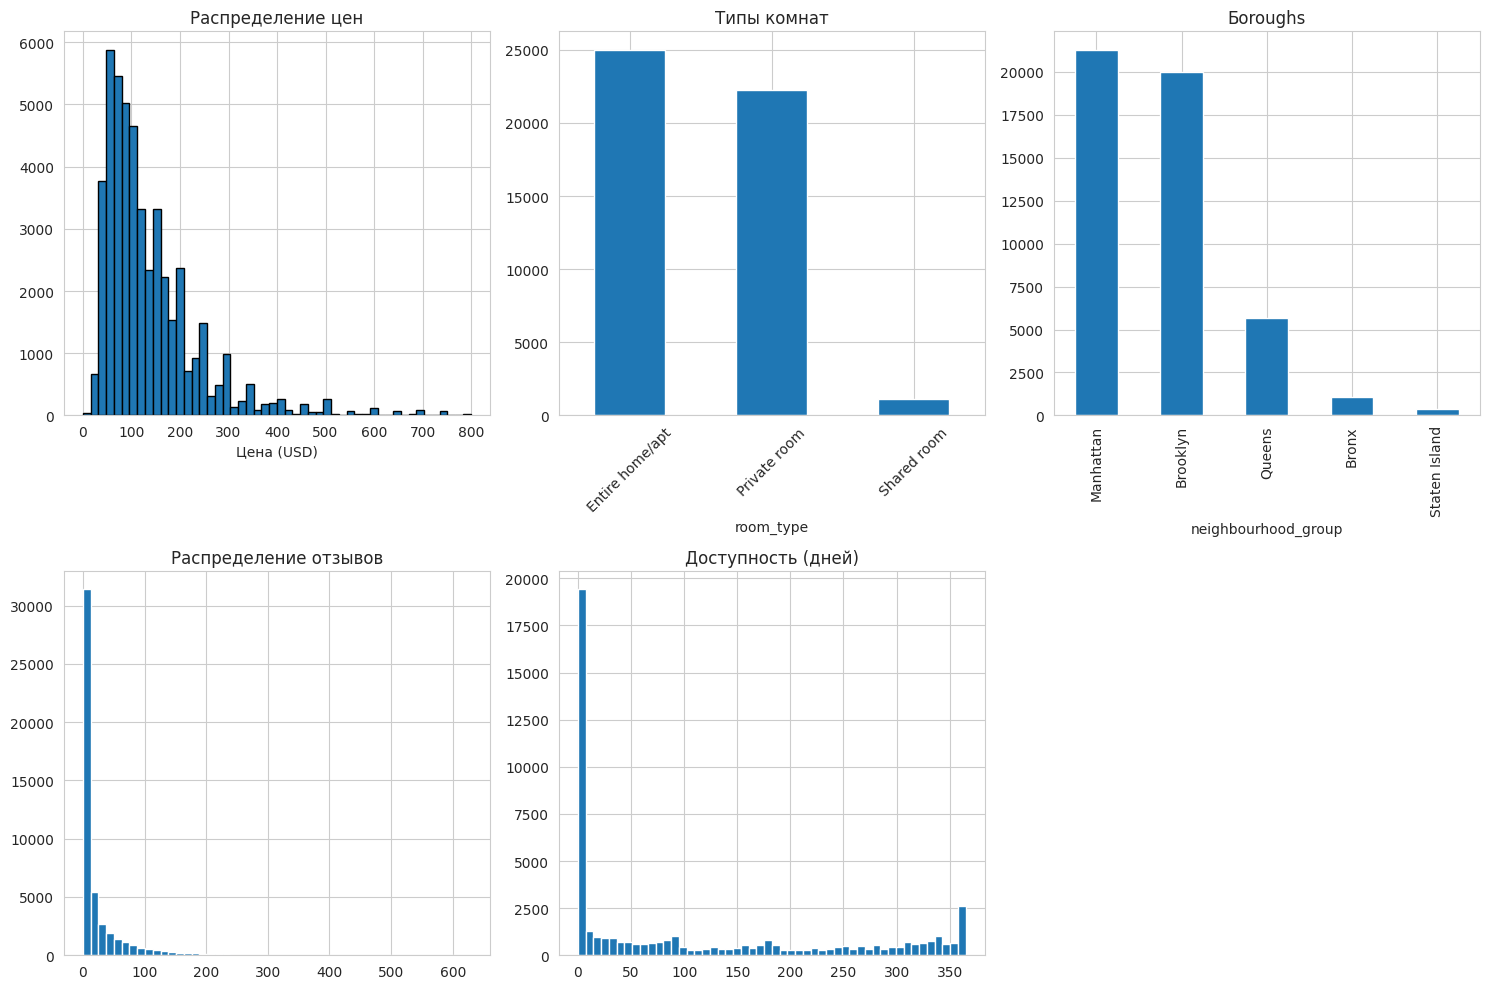

                                       mean  count  median
neighbourhood_group room_type                             
Bronx               Entire home/apt  125.33    377   100.0
                    Private room      63.05    651    53.0
                    Shared room       45.83     58    38.0
Brooklyn            Entire home/apt  165.42   9475   145.0
                    Private room      72.09  10098    65.0
                    Shared room       50.53    413    36.0
Manhattan           Entire home/apt  216.92  12897   190.0
                    Private room     106.57   7921    90.0
                    Shared room       84.09    477    69.0
Queens              Entire home/apt  140.81   2087   120.0
                    Private room      67.77   3366    60.0
                    Shared room       49.31    195    37.0
Staten Island       Entire home/apt  131.09    172   100.0
                    Private room      62.29    188    50.0

Топ-10 районов по отзывам:
 neighbourhood
Bedford-Stuyv

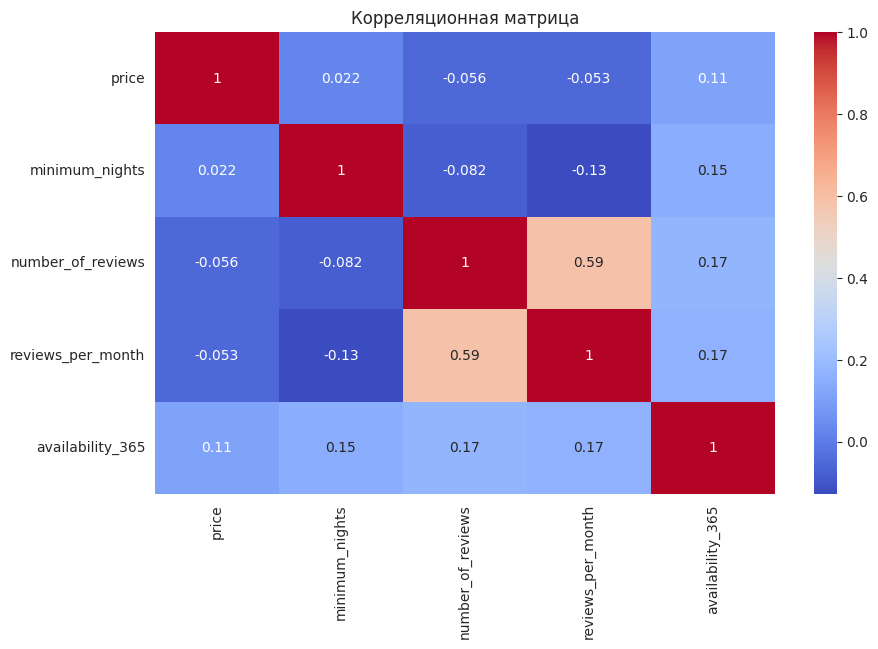

Топ-10 выгодных listings:
                                                     name neighbourhood_group  \
25433      ★Hostel Style Room | Ideal Traveling Buddies★               Bronx   
25794  Spacious comfortable master bedroom with nice ...            Brooklyn   
25795  Contemporary bedroom in brownstone with nice view            Brooklyn   
25796       Cozy yet spacious private brownstone bedroom            Brooklyn   
27972      Spacious 2-bedroom Apt in Heart of Greenpoint            Brooklyn   
20992            Spacious and Modern 2 Bedroom Apartment            Brooklyn   
19922       Evergreen Upper Bed for Female Traveler 紐約民宿            Brooklyn   
957                      Enjoy Staten Island Hospitality       Staten Island   
21733     Partitioned (shared) Cozy Studio in Pelham Bay               Bronx   
37093   Beautiful furnished private studio with backyard              Queens   

             room_type  price  number_of_reviews  
25433     Private room      0            

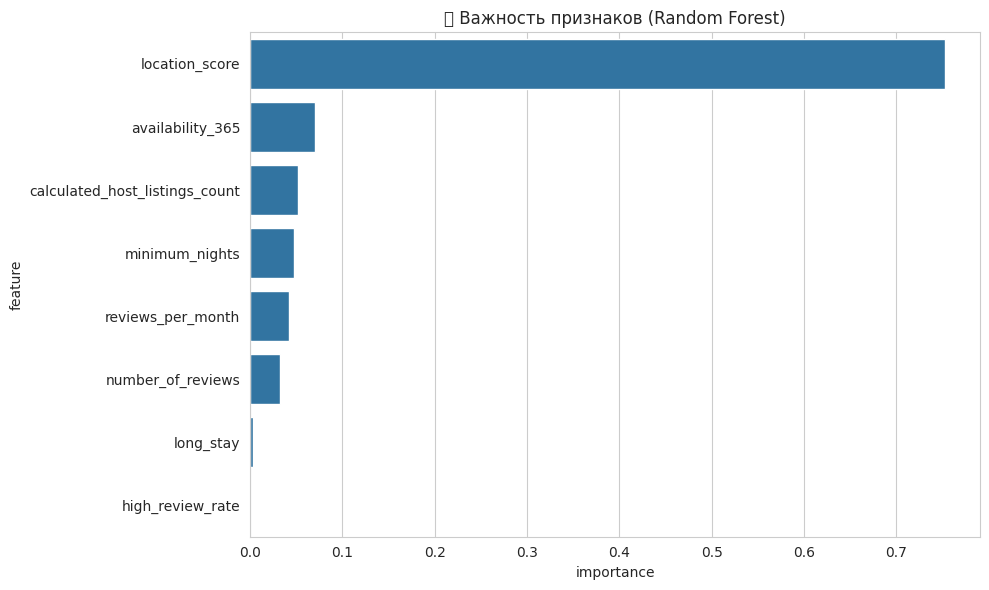

🔍 Feature Importance:
                          feature  importance
7                  location_score       0.753
4                availability_365       0.071
3  calculated_host_listings_count       0.052
0                  minimum_nights       0.047
2               reviews_per_month       0.042
1               number_of_reviews       0.033
6                       long_stay       0.003
5                high_review_rate       0.000

🧪 Эксперимент 1: Топ-5 признаков
RMSE: 0.485 (деградация: 2.8%)
MAE: $49

🧪 Эксперимент 2: Автоматический отбор (k=8)
RMSE: 0.457
🏆 СРАВНЕНИЕ МОДЕЛЕЙ
 RMSE_log MAE_original
Linear Regression 0.484000 49.287000
Ridge Regression 0.484000 49.288000
Random Forest 0.457000 46.287000


⭐ ЛУЧШАЯ МОДЕЛЬ: Random Forest
  RMSE (log): 0.457
  MAE (USD):  $46
🔮 Прогноз для нового листинга:
Ожидаемая цена: $80


In [4]:

import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
print("✅")


path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")
print("Путь к файлам:", path)

filename = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, filename))

print(f"Размер датасета: {df.shape}")
print("\nКолонки:", df.columns.tolist())
df.head()

# Основная информация
print(df.info())
print("\nСтатистика:")
print(df.describe())

# Проверяю пропуски
print("\nПропуски:")
print(df.isnull().sum())

# Удаляю дубликаты
df.drop_duplicates(inplace=True)
print(f"После удаления дубликатов: {df.shape}")

# Обрабатываю пропуски
df['reviews_per_month'].fillna(0, inplace=True)
df.dropna(subset=['name', 'host_name'], inplace=True)

# Удаляю выбросы по цене (top 1%)
price_threshold = df['price'].quantile(0.99)
df = df[df['price'] <= price_threshold]
print(f"После очистки: {df.shape}")

plt.figure(figsize=(15, 10))

# Распределение цен
plt.subplot(2, 3, 1)
df['price'].hist(bins=50, edgecolor='black')
plt.title('Распределение цен')
plt.xlabel('Цена (USD)')

# Room_type
plt.subplot(2, 3, 2)
df['room_type'].value_counts().plot(kind='bar')
plt.title('Типы комнат')
plt.xticks(rotation=45)

# Neighbourhood_group
plt.subplot(2, 3, 3)
df['neighbourhood_group'].value_counts().plot(kind='bar')
plt.title('Бoroughs')

# Кол-во отзывов
plt.subplot(2, 3, 4)
df['number_of_reviews'].hist(bins=50)
plt.title('Распределение отзывов')

# Доступность
plt.subplot(2, 3, 5)
df['availability_365'].hist(bins=50)
plt.title('Доступность (дней)')

plt.tight_layout()
plt.show()

# Средняя цена по типам комнат и borough
price_analysis = df.groupby(['neighbourhood_group', 'room_type'])['price'].agg(['mean', 'count', 'median']).round(2)
price_analysis = price_analysis[price_analysis['count'] >= 10]  # Только значимые группы
print(price_analysis)

# Топ-10 neighbourhoods по отзывам
top_neigh = df.groupby('neighbourhood')['number_of_reviews'].sum().nlargest(10)
print("\nТоп-10 районов по отзывам:\n", top_neigh)

# Корреляция
plt.figure(figsize=(10, 6))
numeric_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()

import folium
from folium import plugins

# Карта Манхэттена
map_airbnb = folium.Map(location=[40.75, -73.96], zoom_start=11)

# Добавляю точки (семпл 1000 для скорости)
sample = df.sample(1000)
for idx, row in sample.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3,
        popup=f"Price: ${row['price']}<br>Type: {row['room_type']}",
        color='blue' if row['price'] < 150 else 'red',
        fill=True
    ).add_to(map_airbnb)

map_airbnb.save('airbnb_map.html')
map_airbnb  # Отобразить в notebook

# Самые выгодные варианты: низкая цена + много отзывов
value_listings = df[(df['price'] < 100) & (df['number_of_reviews'] > 50)].nsmallest(10, 'price')
print("Топ-10 выгодных listings:\n", value_listings[['name', 'neighbourhood_group', 'room_type', 'price', 'number_of_reviews']])

# Создаю копию для работы
df_clean = df.copy()

# Выбросы по цене
price_threshold = df_clean['price'].quantile(0.99)
df_clean = df_clean[df_clean['price'] <= price_threshold]

df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)
df_clean['name'] = df_clean['name'].fillna('Unknown')
df_clean['host_name'] = df_clean['host_name'].fillna('Unknown')

df_clean.drop_duplicates(inplace=True)

print(f"✅ После очистки: {df_clean.shape}")
print(f"Цены: ${df_clean['price'].min():.0f} - ${df_clean['price'].max():.0f}")

# Инженерия признаков
df_features = df_clean.copy()

# Географические признаки
df_features['price_per_review'] = df_features['price'] / (df_features['number_of_reviews'] + 1)
df_features['high_review_rate'] = (df_features['number_of_reviews'] > df_features['number_of_reviews'].quantile(0.75)).astype(int)
df_features['long_stay'] = (df_features['minimum_nights'] > 7).astype(int)

# Геокодированные группы
df_features['location_score'] = (
    df_features['neighbourhood_group'].map({'Manhattan': 3, 'Brooklyn': 2, 'Queens': 1, 'Staten Island': 0, 'Bronx': 0}) +
    df_features['room_type'].map({'Entire home/apt': 2, 'Private room': 1, 'Shared room': 0}
))

print("✅ Новые признаки созданы")
print(df_features[['price_per_review', 'high_review_rate', 'long_stay', 'location_score']].head())

# Признаки для моделирования
feature_cols = ['minimum_nights', 'number_of_reviews', 'reviews_per_month',
                'calculated_host_listings_count', 'availability_365',
                'high_review_rate', 'long_stay', 'location_score']

X = df_features[feature_cols].copy()
y = np.log1p(df_features['price'])  # log(price + 1) для нормализации

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Train: {X_train.shape}, Test: {X_test.shape}")

# Пайплайн обработки
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_train_prepared = pipeline.fit_transform(X_train)
X_test_prepared = pipeline.transform(X_test)

results = {}

lr = LinearRegression()
lr.fit(X_train_prepared, y_train)
lr_pred = lr.predict(X_test_prepared)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(np.expm1(y_test), np.expm1(lr_pred))

results['Linear Regression'] = {'RMSE_log': lr_rmse, 'MAE_original': lr_mae}

print("📏 Linear Regression:")
print(f"RMSE (log): {lr_rmse:.3f}")
print(f"MAE (оригинал): ${lr_mae:.0f}")

ridge = Ridge(alpha=10)
ridge.fit(X_train_prepared, y_train)
ridge_pred = ridge.predict(X_test_prepared)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_mae = mean_absolute_error(np.expm1(y_test), np.expm1(ridge_pred))

results['Ridge Regression'] = {'RMSE_log': ridge_rmse, 'MAE_original': ridge_mae}

print("\n🏔️ Ridge Regression:")
print(f"RMSE (log): {ridge_rmse:.3f}")
print(f"MAE (оригинал): ${ridge_mae:.0f}")

# Подбор параметров
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1
)
rf_grid.fit(X_train_prepared, y_train)

rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test_prepared)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(np.expm1(y_test), np.expm1(rf_pred))

results['Random Forest'] = {'RMSE_log': rf_rmse, 'MAE_original': rf_mae}

print("\n🌲 Random Forest (лучшие параметры):")
print(rf_grid.best_params_)
print(f"RMSE (log): {rf_rmse:.3f}")
print(f"MAE (оригинал): ${rf_mae:.0f}")

# Важность признаков
importances = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances, x='importance', y='feature')
plt.title('🏆 Важность признаков (Random Forest)')
plt.tight_layout()
plt.show()

print("🔍 Feature Importance:")
print(importances.round(3))

top5_features = importances.head(5)['feature'].tolist()
X_top5_train = X_train[top5_features]
X_top5_test = X_test[top5_features]

rf_top5 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_top5.fit(X_top5_train, y_train)
top5_pred = rf_top5.predict(X_top5_test)
top5_rmse = np.sqrt(mean_squared_error(y_test, top5_pred))
top5_mae = mean_absolute_error(np.expm1(y_test), np.expm1(top5_pred))

print("\n🧪 Эксперимент 1: Топ-5 признаков")
print(f"RMSE: {top5_rmse:.3f} (деградация: {(top5_rmse - rf_rmse)*100:.1f}%)")
print(f"MAE: ${top5_mae:.0f}")

selector = SelectKBest(score_func=f_regression, k=8)
X_selected_train = selector.fit_transform(X_train_prepared, y_train)
X_selected_test = selector.transform(X_test_prepared)

rf_selected = RandomForestRegressor(**rf_grid.best_params_, random_state=42)
rf_selected.fit(X_selected_train, y_train)
selected_pred = rf_selected.predict(X_selected_test)
selected_rmse = np.sqrt(mean_squared_error(y_test, selected_pred))

print("\n🧪 Эксперимент 2: Автоматический отбор (k=8)")
print(f"RMSE: {selected_rmse:.3f}")

results_df = pd.DataFrame(results).T.round(3)
print("🏆 СРАВНЕНИЕ МОДЕЛЕЙ")
print(results_df.style.highlight_min(axis=0, color='lightgreen').to_string())

best_model = min(results, key=lambda x: results[x]['RMSE_log'])
print(f"\n⭐ ЛУЧШАЯ МОДЕЛЬ: {best_model}")
print(f"  RMSE (log): {results[best_model]['RMSE_log']:.3f}")
print(f"  MAE (USD):  ${results[best_model]['MAE_original']:.0f}")

# Пример предсказания для нового листинга
new_listing = pd.DataFrame({
    'minimum_nights': [3],
    'number_of_reviews': [50],
    'reviews_per_month': [2.5],
    'calculated_host_listings_count': [2],
    'availability_365': [200],
    'high_review_rate': [1],
    'long_stay': [0],
    'location_score': [3]  # Manhattan + Entire home
})

new_listing_prepared = pipeline.transform(new_listing)
predicted_log_price = rf_best.predict(new_listing_prepared)[0]
predicted_price = np.expm1(predicted_log_price)

print("🔮 Прогноз для нового листинга:")
print(f"Ожидаемая цена: ${predicted_price:.0f}")


#YOUR CODE HERE